# Customer Segmentation — Final Analysis
### JAKALA × LUISS Business Case — *Data Science in Action* A.Y. 2025/26

**Pipeline:** `data_processing.py` → `clustering_model.py` → Business strategy  
**Algorithm:** UMAP (3D) + Gaussian Mixture Model · K = 6 (locked)  
**Data:** `master_transactions.csv` · ~21,000 customers · 24 months (Mar 2023 – Feb 2025)

---
## Phase 0 — Economic Context: Why This Project

> *"Data is the new oil — but unlike oil, it gains value when refined and shared, not when hoarded."*

A major Italian fashion retailer manages roughly **21,000 active customers** over a two-year horizon.  
The marketing team was running **one-size-fits-all campaigns**: same message, same offer, same frequency for everyone. This generates:

- **Budget waste** on already-loyal customers (who would buy regardless)
- **Margin erosion** on deal-seekers (who wait exclusively for sales)
- **Silent churn** of VIP customers (who feel invisible)

**Goal:** Identify distinct behavioural profiles to enable personalised, measurable, ROI-positive campaigns.

In [23]:
import sys
from pathlib import Path

# Add src/ to path so project modules are importable
sys.path.insert(0, str(Path('.').resolve() / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# ── Project modules ─────────────────────────────────────────────────────────
from data_processing import (
    load_master, clean_master, build_customer_matrix, get_clustering_features,
)
from clustering_model import (
    winsorize, scale_features, reduce_umap,
    select_k_bic, fit_gmm, evaluate_clustering,
    save_model, FIXED_K,
)

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
Path('assets').mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)
MASTER_PATH = 'master_transactions.csv'

print(f'Setup complete. FIXED_K = {FIXED_K}')

Setup complete. FIXED_K = 6


---
## Phase 1 — Data Preparation & Quality

The `master_transactions.csv` file is a **pre-assembled denormalized table**: each row is one  
transaction line item with customer demographics and email campaign metrics attached.

**Key cleaning steps:**
1. Parse three date columns in `DDMONYYYY` format
2. Fill missing newsletter metrics with 0 (no subscription = zero engagement)
3. Drop rows without `customer_id` or `Date`
4. Remove **~56 accounting anomalies** — customers where `return_value > gross_spend`  
   (B2B resellers, multi-account holders, or data-entry errors)

In [24]:
# ── Load raw data ───────────────────────────────────────────────────────────
df_raw = load_master(MASTER_PATH)
print(f'Raw dataset : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Unique customers (raw): {df_raw["customer_id"].nunique():,}')
print(f'Date range  : {df_raw["Date"].min().date()} → {df_raw["Date"].max().date()}')

# Light clean for EDA (transaction-level visuals)
df_eda = clean_master(df_raw)

# ── Data quality report ─────────────────────────────────────────────────────
print('\n=== DATA QUALITY REPORT ===')
print(f'Missing values per column (top 10):')
missing = df_eda.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(10).to_string())

print(f'\nReturn rate (line level): {df_eda["is_return"].mean():.1%}')
print(f'Customers with newsletter: {(df_eda.groupby("customer_id")["nl_count"].max() > 0).sum():,}')

Raw dataset : 102,655 rows × 24 columns
Unique customers (raw): 21,480
Date range  : 2023-03-01 → 2025-02-28

=== DATA QUALITY REPORT ===
Missing values per column (top 10):
Size             6742
province_code    4859

Return rate (line level): 7.6%
Customers with newsletter: 16,842


---
## Phase 2 — Exploratory Data Analysis

Key empirical observations that motivate the segmentation design:
- **Pareto law confirmed**: top 20% of customers drive ~78% of revenue
- **High one-timer rate**: ~40% of customers purchased only once — structurally different from repeat buyers
- **Email engagement varies widely**: a subset of customers has consistently high click rates — a signal of brand loyalty
- **Discount dependency**: a cluster of customers shops almost exclusively during January / July sale periods

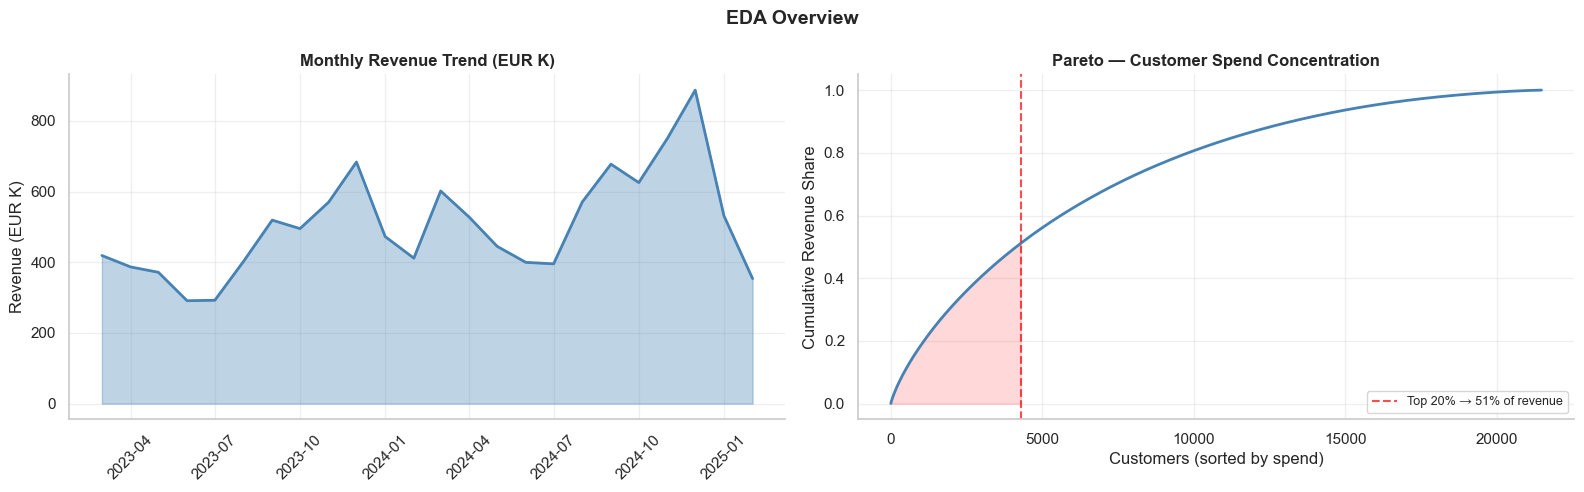

Top 20% of customers → 51.2% of total revenue (Pareto confirmed)


In [25]:
# ── 2.1 Sales Trend & Pareto ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

purchases_eda = df_eda[df_eda['is_return'] == 0].copy()

# Monthly revenue
monthly = (
    purchases_eda.groupby(purchases_eda['Date'].dt.to_period('M'))['line_amount']
    .sum().reset_index()
)
monthly['Date'] = monthly['Date'].dt.to_timestamp()
axes[0].fill_between(monthly['Date'], monthly['line_amount'] / 1e3, alpha=0.35, color='steelblue')
axes[0].plot(monthly['Date'], monthly['line_amount'] / 1e3, color='steelblue', linewidth=2)
axes[0].set_title('Monthly Revenue Trend (EUR K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue (EUR K)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# Pareto
cust_spend = purchases_eda.groupby('customer_id')['line_amount'].sum().sort_values(ascending=False)
cumsum = cust_spend.cumsum() / cust_spend.sum()
top20_idx   = int(len(cumsum) * 0.20)
top20_share = cumsum.iloc[top20_idx]
axes[1].plot(range(len(cumsum)), cumsum.values, color='steelblue', linewidth=2)
axes[1].axvline(x=top20_idx, color='red', linestyle='--', alpha=0.7,
                label=f'Top 20% → {top20_share:.0%} of revenue')
axes[1].fill_between(range(top20_idx), cumsum.values[:top20_idx], alpha=0.15, color='red')
axes[1].set_title('Pareto — Customer Spend Concentration', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Customers (sorted by spend)')
axes[1].set_ylabel('Cumulative Revenue Share')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('EDA Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top 20% of customers → {top20_share:.1%} of total revenue (Pareto confirmed)')

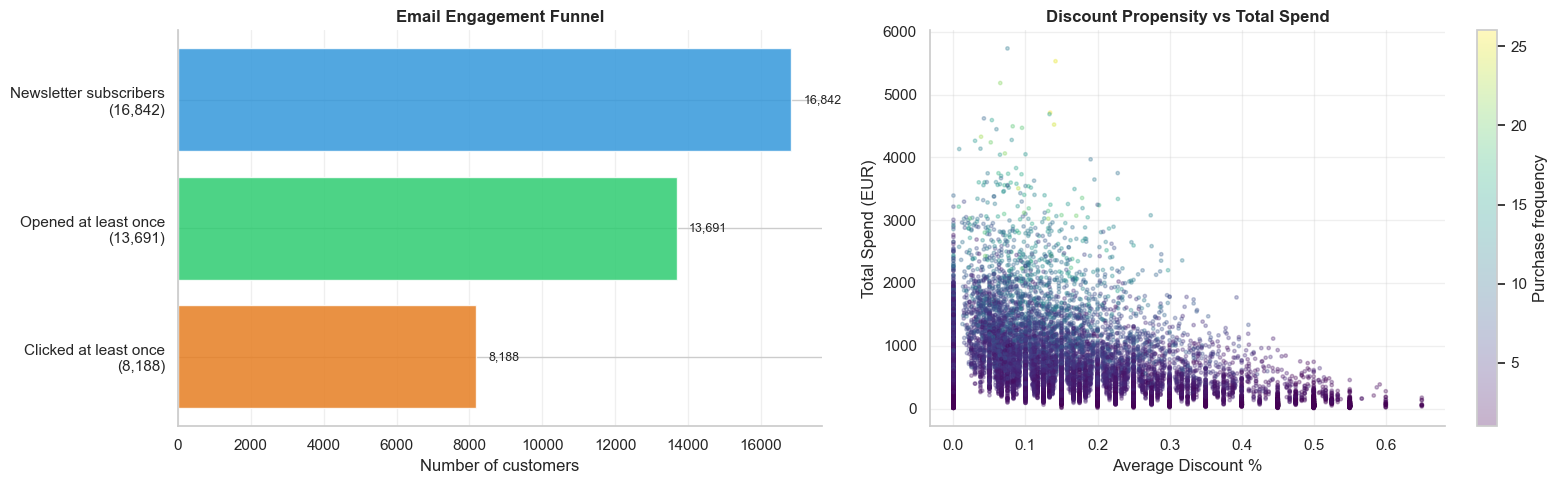

In [26]:
# ── 2.2 Email Engagement Funnel ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

nl_agg = df_eda.groupby('customer_id').agg(
    sent=('nl_count', 'max'),
    open_rate=('nl_open_rate', 'max'),
    click_rate=('nl_click_rate', 'max')
).reset_index()

subscribers = int((nl_agg['sent'] > 0).sum())
openers     = int((nl_agg['open_rate'] > 0).sum())
clickers    = int((nl_agg['click_rate'] > 0).sum())

funnel_vals = [subscribers, openers, clickers]
funnel_lbls = [f'Newsletter subscribers\n({subscribers:,})',
               f'Opened at least once\n({openers:,})',
               f'Clicked at least once\n({clickers:,})']
colors_nl = ['#3498DB', '#2ECC71', '#E67E22']
bars = axes[0].barh(funnel_lbls, funnel_vals, color=colors_nl, alpha=0.85)
for bar, val in zip(bars, funnel_vals):
    axes[0].text(val + max(funnel_vals) * 0.02, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_title('Email Engagement Funnel', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of customers')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# Discount vs spend
disc_sc = purchases_eda.groupby('customer_id').agg(
    avg_disc=('discount_percentage', 'mean'),
    total_spend=('line_amount', 'sum'),
    freq=('Date', 'nunique')
).reset_index()
sc = axes[1].scatter(disc_sc['avg_disc'], disc_sc['total_spend'],
                     c=disc_sc['freq'], cmap='viridis', alpha=0.3, s=6)
plt.colorbar(sc, ax=axes[1], label='Purchase frequency')
axes[1].set_xlabel('Average Discount %')
axes[1].set_ylabel('Total Spend (EUR)')
axes[1].set_title('Discount Propensity vs Total Spend', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('assets/eda_email_discount.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 3 — Behavioural Feature Engineering

`build_customer_matrix()` aggregates the transaction dataset into a **1-row-per-customer matrix**  
with ~32 behavioural features across 6 dimensions:

| Dimension | Features |
|-----------|---------|
| **RFM** | recency_days, frequency, monetary, avg_basket_value |
| **Discount propensity** | avg_discount_pct, pct_items_discounted, pct_spend_in_sale_season |
| **Email engagement** | nl_open_rate, nl_click_rate, engagement_score |
| **Return behaviour** | return_rate |
| **Category affinity** | n_categories_explored, pct_outerwear, pct_tops, … (7 categories) |
| **Channel mix** | ecommerce_share, outlet_share |

*Demographics (age, tenure, gender, province) are included for profiling but excluded from the clustering feature vector.*

In [27]:
# ── Build customer matrix ───────────────────────────────────────────────────
# build_customer_matrix() handles cleaning, anomaly removal, and all feature groups internally
customer_matrix = build_customer_matrix(df_raw, verbose=True)

print(f'\nCustomer matrix: {customer_matrix.shape[0]:,} customers × {customer_matrix.shape[1]} features')

# Preview
preview_cols = ['customer_id', 'recency_days', 'frequency', 'monetary',
                'avg_discount_pct', 'engagement_score', 'return_rate', 'n_categories_explored']
preview_cols = [c for c in preview_cols if c in customer_matrix.columns]
print('\n--- Sample rows ---')
print(customer_matrix[preview_cols].head(5).to_string(index=False))
print('\n--- Descriptive stats (key features) ---')
print(customer_matrix[preview_cols[1:]].describe().round(2).to_string())

[build_customer_matrix] Input: 102,655 transaction rows
  Anomalies removed : 56 customers (return_value > gross_spend)
  Reference date    : 2025-02-28
  Customer matrix   : 21,424 customers × 37 features

Customer matrix: 21,424 customers × 37 features

--- Sample rows ---
customer_id  recency_days  frequency  monetary  avg_discount_pct  engagement_score  return_rate  n_categories_explored
   A0356882            52          7  1292.000             0.061             0.133        0.471                      6
   A0357266            30          6  1158.000             0.044             0.308        0.385                      4
   A0357328            93          5   699.700             0.075             0.229        0.400                      3
   A0357849            20          3   616.000             0.000             0.000        0.333                      3
   A0358076           532          7  1138.600             0.020             0.373        0.333                      7

--- Descr

---
## Phase 4 — Dimensionality Reduction with UMAP

**Why UMAP instead of PCA?**

- **PCA** preserves *linear* variance — customer behavioural data is highly non-linear
- **UMAP** preserves *local topological structure*, making behavioural sub-groups separable  
  even when they are not linearly separable in the original 32-dimensional space
- UMAP is fitted in **3D for clustering** (captures richer topology) and **2D for visualisation**

**Preprocessing pipeline:**
1. `winsorize()` — cap values at the 99th percentile (residual outlier handling)
2. `scale_features()` — RobustScaler (robust to remaining outliers post-winsorization)
3. `reduce_umap()` — UMAP embedding

In [28]:
# ── 4.1 Feature extraction + winsorization + scaling ────────────────────────
_, clustering_cols = get_clustering_features(customer_matrix)

# Winsorize in the customer_matrix space (cap outliers at 99th percentile)
customer_matrix_w = winsorize(customer_matrix, clustering_cols, quantile=0.99)

# Extract feature matrix and apply RobustScaler
X, feature_names = get_clustering_features(customer_matrix_w)
X_scaled, scaler = scale_features(X)

print(f'Clustering features ({len(feature_names)}):')
for f in sorted(feature_names):
    print(f'  - {f}')
print(f'\nFeature matrix : {X.shape}')
print(f'Scaled matrix  : {X_scaled.shape} — mean≈{X_scaled.mean():.3f}, std≈{X_scaled.std():.3f}')

Clustering features (24):
  - age_years
  - avg_basket_value
  - avg_discount_pct
  - ecommerce_share
  - engagement_score
  - frequency
  - is_one_timer
  - monetary
  - n_categories_explored
  - nl_click_rate
  - nl_open_rate
  - outlet_share
  - pct_accessories
  - pct_bottoms
  - pct_child
  - pct_items_discounted
  - pct_outerwear
  - pct_spend_in_sale_season
  - pct_sportswear
  - pct_tops
  - pct_underwear_and_nightwear
  - recency_days
  - return_rate
  - tenure_days

Feature matrix : (21424, 24)
Scaled matrix  : (21424, 24) — mean≈0.229, std≈0.786


In [29]:
# ── 4.2 UMAP dimensionality reduction ───────────────────────────────────────
print('Fitting UMAP 3D (for clustering)...')
X_umap_3d, reducer_3d = reduce_umap(X_scaled, n_components=3,
                                     n_neighbors=30, min_dist=0.1, seed=SEED)
print('Fitting UMAP 2D (for visualisation)...')
X_umap_2d, reducer_2d = reduce_umap(X_scaled, n_components=2,
                                     n_neighbors=30, min_dist=0.1, seed=SEED)

customer_matrix['umap_x'] = X_umap_2d[:, 0]
customer_matrix['umap_y'] = X_umap_2d[:, 1]

print(f'\nUMAP 3D : {X_umap_3d.shape}')
print(f'UMAP 2D : {X_umap_2d.shape}')

Fitting UMAP 3D (for clustering)...
Fitting UMAP 2D (for visualisation)...

UMAP 3D : (21424, 3)
UMAP 2D : (21424, 2)


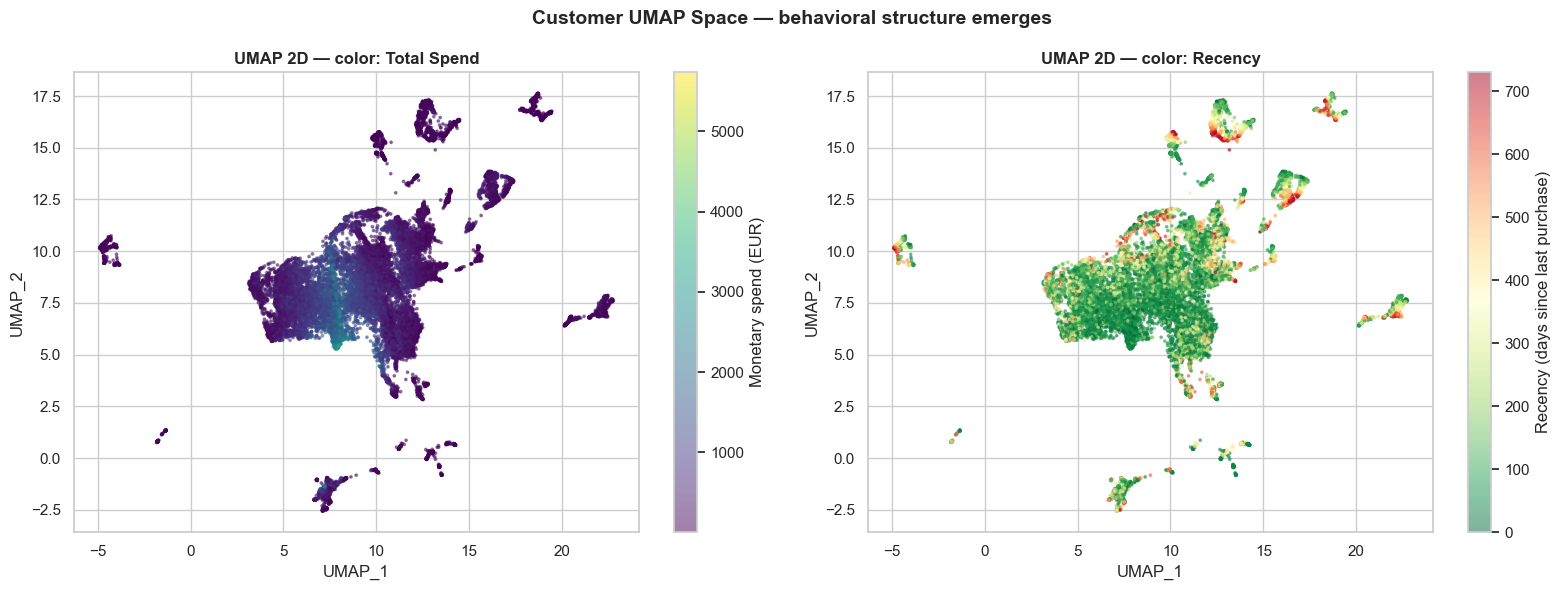

In [30]:
# ── 4.3 UMAP 2D visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1],
                      c=customer_matrix['monetary'], cmap='viridis',
                      alpha=0.5, s=3)
plt.colorbar(sc1, ax=axes[0], label='Monetary spend (EUR)')
axes[0].set_title('UMAP 2D — color: Total Spend', fontsize=12, fontweight='bold')
axes[0].set_xlabel('UMAP_1')
axes[0].set_ylabel('UMAP_2')

sc2 = axes[1].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1],
                      c=customer_matrix['recency_days'], cmap='RdYlGn_r',
                      alpha=0.5, s=3)
plt.colorbar(sc2, ax=axes[1], label='Recency (days since last purchase)')
axes[1].set_title('UMAP 2D — color: Recency', fontsize=12, fontweight='bold')
axes[1].set_xlabel('UMAP_1')
axes[1].set_ylabel('UMAP_2')

plt.suptitle('Customer UMAP Space — behavioral structure emerges', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/umap_space.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 5 — Clustering: UMAP + GMM (K=6)

**Why GMM over K-Means?**
K-Means assumes **spherical, equally-sized clusters** (minimises WCSS = sum of squared distances from centroids).  
Customer behaviour data almost never satisfies this — clusters differ in shape, density, and size.

**GMM advantages:**
- Models clusters with **arbitrary ellipsoidal shape** (`covariance_type='full'`)
- Produces **soft assignment probabilities** — each customer has a confidence score for their segment
- Optimal K selected via **BIC** (Bayesian Information Criterion): penalises model complexity

**K = 6 rationale:** BIC elbow analysis (see cell below) + operational constraint —  
beyond 6 segments, genuinely distinct marketing campaigns become unmanageable (industry benchmark).

*Classic algorithms were tested during exploration:*

| Algorithm | Result | Reason discarded |
|-----------|--------|-----------------|
| K-Means (k=4) | Silhouette ~0.08 | Sphericity assumption; blends behaviorally distinct groups |
| DBSCAN | 1 cluster + 91 noise | "Hairball problem": uniform-density embedding — no natural gaps |
| OPTICS | 1 mega-cluster | Same root cause as DBSCAN |
| Agglomerative HC | Silhouette ~0.06 | Dendrogram shows no clear cuts |
| **UMAP + GMM** ✅ | **K=6** | Preserves topology; handles non-spherical clusters; probabilistic |

K with minimum BIC (diagnostic): 10
Operational K (locked)         : 6


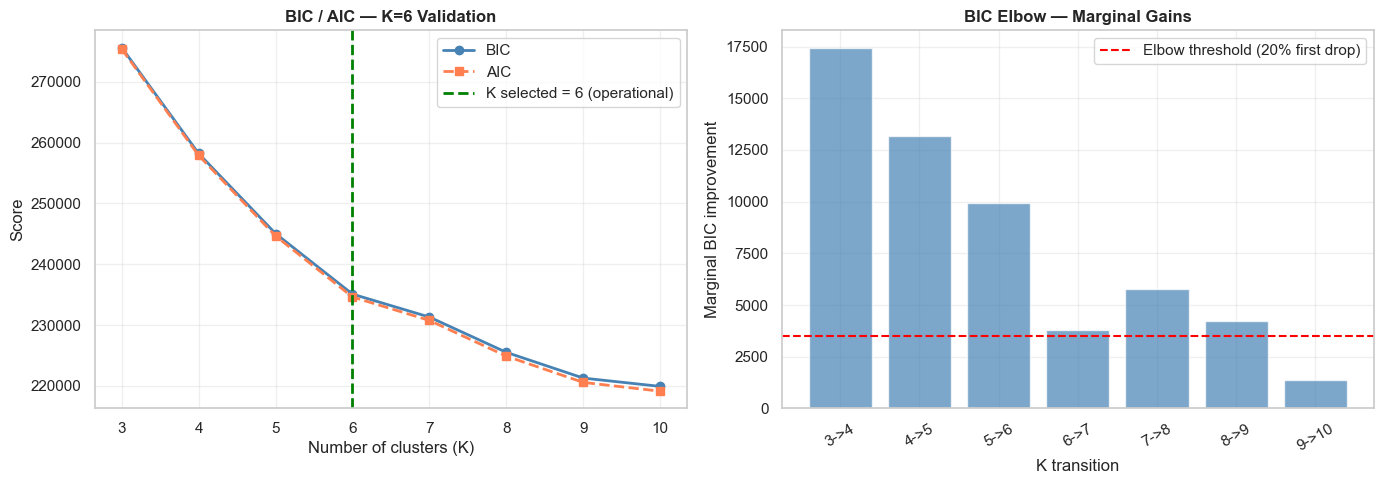

In [31]:
# ── 5.1 BIC/AIC diagnostic — K selection ────────────────────────────────────
# select_k_bic() runs GMM at each K and returns BIC/AIC curves.
# K=6 is locked (FIXED_K) — this cell shows the analytical validation.

K_range = range(3, 11)
k_diag, bic_scores, aic_scores = select_k_bic(X_umap_3d, k_range=K_range,
                                                n_init=5, seed=SEED)

print(f'K with minimum BIC (diagnostic): {k_diag}')
print(f'Operational K (locked)         : {FIXED_K}')

# BIC/AIC plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(K_range, bic_scores, 'o-', color='steelblue', label='BIC', linewidth=2)
ax.plot(K_range, aic_scores, 's--', color='coral', label='AIC', linewidth=2)
ax.axvline(x=FIXED_K, color='green', linewidth=2, linestyle='--',
           label=f'K selected = {FIXED_K} (operational)')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Score')
ax.set_title('BIC / AIC — K=6 Validation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

bic_drops = [bic_scores[i-1] - bic_scores[i] for i in range(1, len(bic_scores))]
ax2 = axes[1]
ax2.bar(range(1, len(bic_drops)+1), bic_drops, color='steelblue', alpha=0.7)
ax2.axhline(y=0.20 * bic_drops[0] if bic_drops[0] > 0 else 0,
            color='red', linestyle='--', label='Elbow threshold (20% first drop)')
ax2.set_xticks(range(1, len(bic_drops)+1))
ax2.set_xticklabels(
    [f'{list(K_range)[i]}->{list(K_range)[i+1]}' for i in range(len(bic_drops))],
    rotation=30
)
ax2.set_xlabel('K transition')
ax2.set_ylabel('Marginal BIC improvement')
ax2.set_title('BIC Elbow — Marginal Gains', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('assets/bic_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ── 5.2 GMM final fit — K=6 ─────────────────────────────────────────────────
gmm_final = fit_gmm(X_umap_3d, k=FIXED_K, n_init=10, seed=SEED)

cluster_labels = gmm_final.predict(X_umap_3d)
cluster_proba  = gmm_final.predict_proba(X_umap_3d)
max_proba      = cluster_proba.max(axis=1)

print(f'Average assignment confidence : {max_proba.mean():.3f}')
print(f'Customers with confidence > 0.8: {(max_proba > 0.8).mean()*100:.1f}%')

customer_matrix['cluster_gmm']        = cluster_labels
customer_matrix['cluster_confidence'] = max_proba

print('\n=== GMM CLUSTER DISTRIBUTION ===')
dist = customer_matrix['cluster_gmm'].value_counts().sort_index()
for cid, n in dist.items():
    print(f'  Cluster {cid}: {n:,} customers ({n/len(customer_matrix)*100:.1f}%)')

Average assignment confidence : 0.983
Customers with confidence > 0.8: 96.5%

=== GMM CLUSTER DISTRIBUTION ===
  Cluster 0: 6,495 customers (30.3%)
  Cluster 1: 10,256 customers (47.9%)
  Cluster 2: 675 customers (3.2%)
  Cluster 3: 2,727 customers (12.7%)
  Cluster 4: 768 customers (3.6%)
  Cluster 5: 503 customers (2.3%)


In [33]:
# ── 5.3 Statistical cluster evaluation ───────────────────────────────────────
metrics = evaluate_clustering(X_umap_3d, cluster_labels, sample_size=5000, seed=SEED)

# UMAP scatter colored by cluster
fig = px.scatter(
    x=X_umap_2d[:, 0],
    y=X_umap_2d[:, 1],
    color=cluster_labels.astype(str),
    opacity=0.5,
    title=f'GMM Clustering K={FIXED_K} — UMAP 2D Space',
    labels={'x': 'UMAP_1', 'y': 'UMAP_2', 'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(height=500)
fig.show()

=== CLUSTERING EVALUATION ===
Silhouette Score     : 0.4188  (higher is better, range [-1, 1])
Davies-Bouldin Index : 0.7604  (lower is better)
Calinski-Harabasz    : 10975.4  (higher is better)


---
## Phase 6 — Cluster Profiling & Business Strategy

Each GMM cluster is back-projected onto the original feature space (pre-UMAP) to compute  
meaningful business metrics per segment. Clusters are then mapped to named **personas**  
using a rank-based scoring algorithm:  
for each persona, the cluster with the most distinctive profile is assigned exclusively.

In [34]:
# ── 6.1 Cluster profile — original feature means ────────────────────────────
_cat_local = [
    c for c in customer_matrix.columns
    if c.startswith('pct_') and c not in ['pct_items_discounted', 'pct_spend_in_sale_season']
]

PROFILE_FEATURES = [
    'recency_days', 'frequency', 'monetary', 'avg_basket_value',
    'avg_discount_pct', 'pct_items_discounted', 'pct_spend_in_sale_season',
    'nl_open_rate', 'nl_click_rate', 'engagement_score',
    'return_rate', 'n_categories_explored', 'age_years', 'tenure_days', 'is_one_timer',
] + _cat_local

PROFILE_FEATURES = [f for f in PROFILE_FEATURES if f in customer_matrix.columns]

profile = customer_matrix.groupby('cluster_gmm')[PROFILE_FEATURES].mean().round(3)
profile['n_customers']   = customer_matrix.groupby('cluster_gmm')['customer_id'].count()
profile['pct_customers'] = (profile['n_customers'] / len(customer_matrix) * 100).round(1)

_show = ['n_customers', 'pct_customers', 'recency_days', 'frequency',
         'monetary', 'avg_basket_value', 'avg_discount_pct',
         'engagement_score', 'return_rate', 'n_categories_explored']
print('=== CLUSTER PROFILE (means) ===')
print(profile[[c for c in _show if c in profile.columns]].to_string())

=== CLUSTER PROFILE (means) ===
             n_customers  pct_customers  recency_days  frequency  monetary  avg_basket_value  avg_discount_pct  engagement_score  return_rate  n_categories_explored
cluster_gmm                                                                                                                                                         
0                   6495         30.300       130.672      5.085   975.365           194.963             0.114             0.253        0.054                  3.995
1                  10256         47.900       198.739      2.730   484.189           196.305             0.117             0.211        0.042                  2.459
2                    675          3.200       315.452      1.101   147.496           134.689             0.103             0.110        0.036                  1.000
3                   2727         12.700       305.457      1.181   114.729            97.693             0.146             0.091        0.028  

In [35]:
# ── 6.2 Persona assignment ──────────────────────────────────────────────────
# 6 personas matching the HTML presentation (presentation_finale.html).
# Rank-based greedy: each persona gets the cluster with the
# highest score on its key dimension. No duplicate assignments possible.

PERSONA_SCORES = {
    "💎 The Inner Circle":
        lambda r: r["monetary"] / (r["recency_days"] + 30),
    "🏷️ Deal Chasers":
        lambda r: r["avg_discount_pct"] * (1 + r.get("pct_items_discounted", 0)),
    "🔄 Quality Seekers":
        lambda r: r.get("engagement_score", 0),
    "👋 Dormant Potential":
        lambda r: r["recency_days"] / (r["monetary"] + 1) * 100,
    "🛍️ Style Explorers":
        lambda r: r.get("n_categories_explored", 0),
    "🌱 Rising Stars":
        lambda r: 0.0,  # fallback — absorbs remaining cluster(s)
}

PRIORITY = [
    "💎 The Inner Circle",
    "🏷️ Deal Chasers",
    "🔄 Quality Seekers",
    "👋 Dormant Potential",
    "🛍️ Style Explorers",
    "🌱 Rising Stars",
]

score_df = pd.DataFrame(index=profile.index,
                        columns=list(PERSONA_SCORES.keys()), dtype=float)
for pname, fn in PERSONA_SCORES.items():
    score_df[pname] = (
        profile.apply(fn, axis=1).astype(float)
        if pname != "🌱 Rising Stars" else 0.0
    )

name_map = {}
assigned = set()
for persona in PRIORITY:
    available = [cid for cid in score_df.index if cid not in assigned]
    if not available:
        break
    if persona == "🌱 Rising Stars":
        for cid in available:
            name_map[cid] = persona
        break
    best = score_df.loc[available, persona].idxmax()
    name_map[best] = persona
    assigned.add(best)

profile['cluster_name']         = pd.Series(name_map)
customer_matrix['cluster_name'] = customer_matrix['cluster_gmm'].map(name_map)

print('\n=== PERSONA ASSIGNMENT ===')
for cid in sorted(name_map):
    n   = (customer_matrix['cluster_gmm'] == cid).sum()
    pct = n / len(customer_matrix) * 100
    print(f'  Cluster {cid}: {name_map[cid]:<40s} ({n:,} customers — {pct:.1f}%)')


=== PERSONA ASSIGNMENT ===
  Cluster 0: 💎 The Inner Circle                       (6,495 customers — 30.3%)
  Cluster 1: 🛍️ Style Explorers                       (10,256 customers — 47.9%)
  Cluster 2: 🌱 Rising Stars                           (675 customers — 3.2%)
  Cluster 3: 🏷️ Deal Chasers                          (2,727 customers — 12.7%)
  Cluster 4: 🔄 Quality Seekers                        (768 customers — 3.6%)
  Cluster 5: 👋 Dormant Potential                      (503 customers — 2.3%)


In [36]:
# ── 6.3 Radar chart (Plotly) ────────────────────────────────────────────────
RADAR_FEATURES = [
    'monetary', 'frequency', 'recency_days',
    'avg_discount_pct', 'engagement_score',
    'return_rate', 'n_categories_explored'
]
RADAR_LABELS = [
    'Spend', 'Frequency', 'Recency (inv.)',
    'Discount', 'Email Engagement',
    'Return Rate', 'Category Breadth'
]
RADAR_FEATURES = [f for f in RADAR_FEATURES if f in profile.columns]
RADAR_LABELS   = RADAR_LABELS[:len(RADAR_FEATURES)]

radar_data = profile[RADAR_FEATURES].copy()
# Invert recency: high days = inactive = lower score
if 'recency_days' in radar_data.columns:
    radar_data['recency_days'] = radar_data['recency_days'].max() - radar_data['recency_days']

radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

colors = px.colors.qualitative.Bold
fig = go.Figure()

for i, (cid, row) in enumerate(radar_norm.iterrows()):
    values = row[RADAR_FEATURES].tolist() + [row[RADAR_FEATURES[0]]]
    labels = RADAR_LABELS + [RADAR_LABELS[0]]
    color  = colors[i % len(colors)]
    name   = name_map.get(cid, f'Cluster {cid}')

    fig.add_trace(go.Scatterpolar(
        r=values, theta=labels, fill='toself', name=name,
        line=dict(color=color, width=2), fillcolor=color, opacity=0.3
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Radar Chart — Customer Segments (Normalised Features)',
    height=600
)
fig.show()

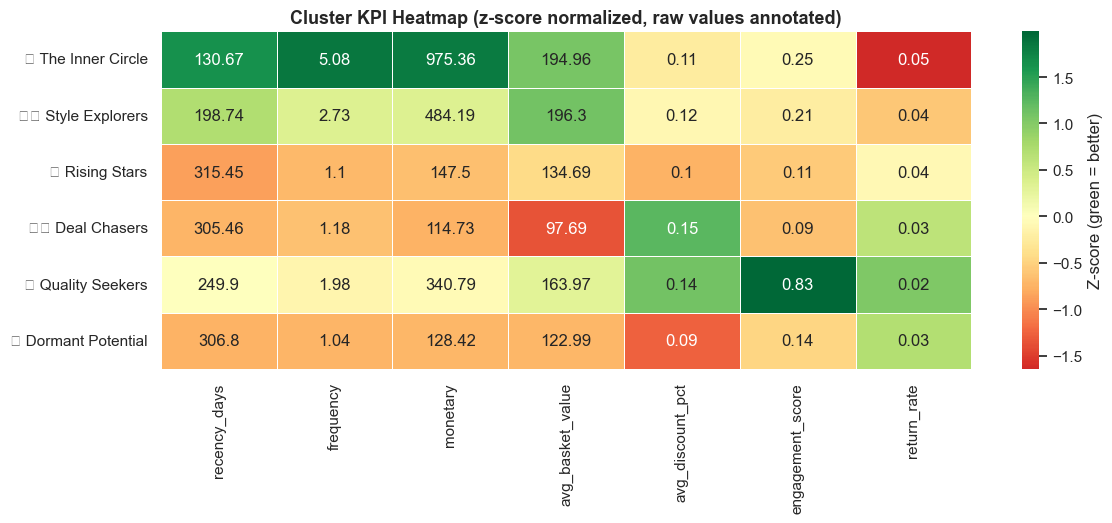

In [37]:
# ── 6.4 KPI Heatmap by cluster ──────────────────────────────────────────────
kpi_cols = ['recency_days', 'frequency', 'monetary', 'avg_basket_value',
            'avg_discount_pct', 'engagement_score', 'return_rate']
kpi_cols = [c for c in kpi_cols if c in profile.columns]

kpi_df = profile[kpi_cols].copy()
kpi_df.index = [name_map.get(cid, f'C{cid}') for cid in kpi_df.index]

# Z-score normalisation
kpi_norm = (kpi_df - kpi_df.mean()) / (kpi_df.std() + 1e-9)
# Invert recency and return rate: higher = worse
for col in ['recency_days', 'return_rate']:
    if col in kpi_norm.columns:
        kpi_norm[col] = -kpi_norm[col]

fig, ax = plt.subplots(figsize=(12, max(5, len(kpi_norm) * 0.9)))
sns.heatmap(kpi_norm, annot=kpi_df.round(2), fmt='g',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Z-score (green = better)'}, ax=ax)
ax.set_title('Cluster KPI Heatmap (z-score normalized, raw values annotated)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('assets/cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

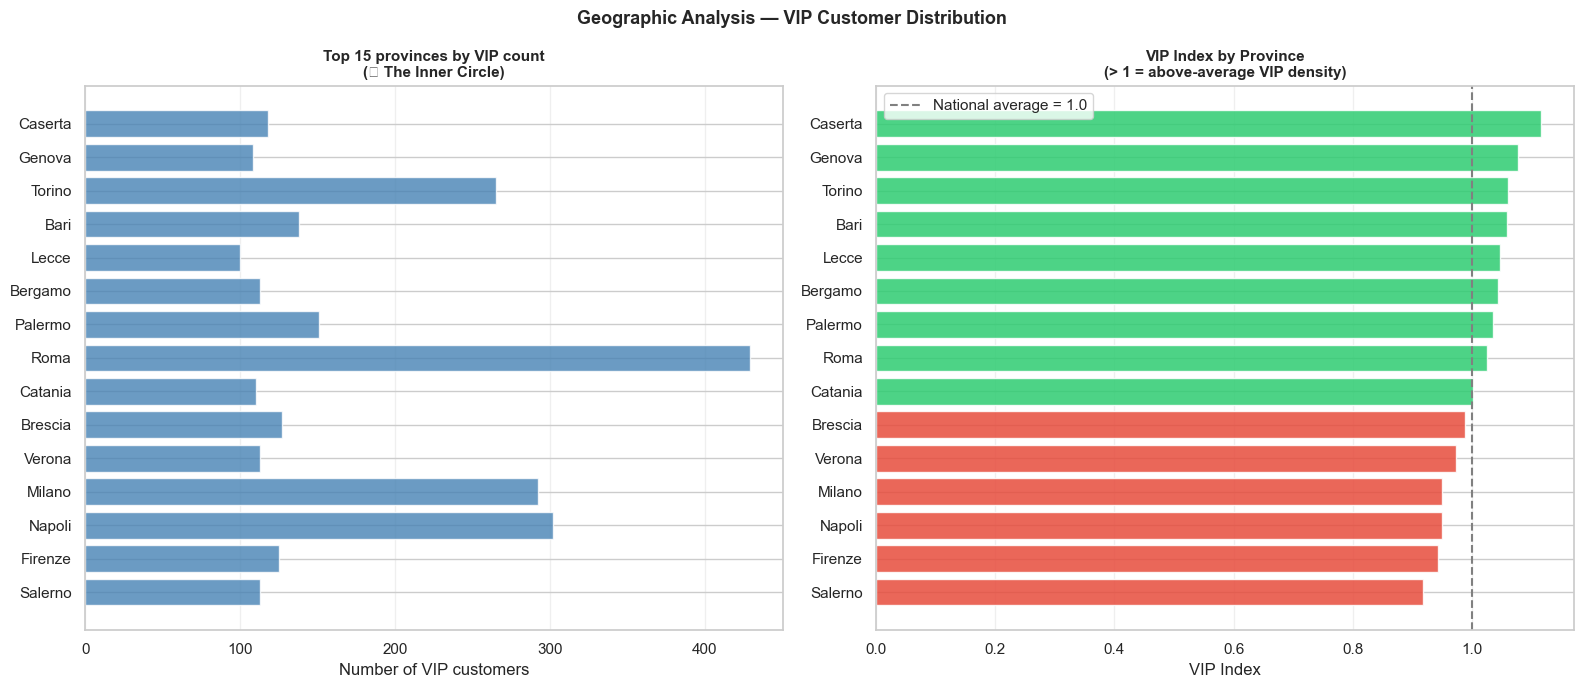

In [38]:
# ── 6.5 Geographic distribution — VIP index ─────────────────────────────────
if 'province' in customer_matrix.columns:
    # Identify the VIP cluster (highest monetary mean)
    vip_cluster = profile['monetary'].idxmax()
    vip_name    = name_map.get(vip_cluster, f'Cluster {vip_cluster}')

    geo = customer_matrix.groupby('province').agg(
        n_total=('customer_id', 'count'),
        n_vip=('cluster_gmm', lambda x: (x == vip_cluster).sum())
    ).reset_index()
    geo['vip_rate']  = geo['n_vip'] / geo['n_total']
    avg_vip_rate     = geo['vip_rate'].mean()
    geo['vip_index'] = geo['vip_rate'] / avg_vip_rate  # >1 = above average VIP density

    top_provinces = geo.nlargest(15, 'n_vip').sort_values('vip_index', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    axes[0].barh(top_provinces['province'], top_provinces['n_vip'],
                 color='steelblue', alpha=0.8)
    axes[0].set_title(f'Top 15 provinces by VIP count\n({vip_name})',
                      fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Number of VIP customers')
    axes[0].grid(axis='x', alpha=0.3)

    colors_idx = ['#2ECC71' if v >= 1 else '#E74C3C' for v in top_provinces['vip_index']]
    axes[1].barh(top_provinces['province'], top_provinces['vip_index'],
                 color=colors_idx, alpha=0.85)
    axes[1].axvline(x=1.0, color='gray', linestyle='--', label='National average = 1.0')
    axes[1].set_title('VIP Index by Province\n(> 1 = above-average VIP density)',
                      fontsize=11, fontweight='bold')
    axes[1].set_xlabel('VIP Index')
    axes[1].legend()
    axes[1].grid(axis='x', alpha=0.3)

    plt.suptitle('Geographic Analysis — VIP Customer Distribution', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('assets/geo_vip.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Province column not available — skipping geographic analysis.')

In [39]:
# ── 6.6 Business strategy by segment ────────────────────────────────────────
BUSINESS_STRATEGIES = {
    '💎 The Inner Circle': {
        'objective': 'RETENTION + UP-SELLING',
        'lever':     'VIP Early Access: exclusive invitations to collection previews, '
                     'personal shopper, loyalty programme with platinum tier.',
        'impact':    'High. Represents the revenue core (Pareto ~80%). '
                     'Reducing churn by 5% here is worth more than acquiring 500 new customers. '
                     'KPI: VIP churn rate, 12-month CLV.',
    },
    '🏷️ Deal Chasers': {
        'objective': 'UP-SELLING + REDUCTION OF DISCOUNT DEPENDENCY',
        'lever':     'A/B test: discount email (control) vs editorial + bundle value (treatment). '
                     'Loyalty points instead of % discount. Targeted flash sales on unexplored categories.',
        'impact':    'Medium. Risk of margin cannibalization. '
                     'Goal: shift 20% of purchases from sale to full-price. '
                     'KPI: Gross margin per customer, % full-price purchases.',
    },
    '🔄 Quality Seekers': {
        'objective': 'REFERRAL + ADVOCACY + UPSELL',
        'lever':     'Referral programme with bilateral incentives. '
                     'UGC campaigns on social media. Exclusive brand event invitations. '
                     'Premium editorial newsletter. NPS survey.',
        'impact':    'Medium-High. Low acquisition cost for referral customers. '
                     'KPI: Referral rate, NPS, CLV referral vs organic.',
    },
    '👋 Dormant Potential': {
        'objective': 'SECOND PURCHASE (Conversion)',
        'lever':     'Post-purchase email at 30 days: "How is your [purchased category]?" '
                     '+ complementary product. At 60 days: 10% expiring voucher. '
                     'Exit-intent popup on second visit.',
        'impact':    'Very high in volume terms (often the largest cluster). '
                     'Converting 15% into repeat buyers drastically changes average LTV. '
                     'KPI: 2nd purchase rate at 90/180 days.',
    },
    '🛍️ Style Explorers': {
        'objective': 'CROSS-SELLING + DEEPENING',
        'lever':     '"Complete the Look" outfit recommendation engine via email and on-site. '
                     'Bundle categories with small incentive (10% off accessory with outerwear). '
                     'Upsell on premium tier.',
        'impact':    'High. Naturally multi-category customers — high conversion on recommendations. '
                     'KPI: Avg categories per order, cross-category conversion rate.',
    },
    '🌱 Rising Stars': {
        'objective': 'NURTURING + TIER UPGRADE',
        'lever':     'Gamified loyalty programme ("X points from Silver tier!"). '
                     'Editorial newsletter on seasonal trends. '
                     'Invitations to local events. Light personalisation on preferred category.',
        'impact':    'Medium. These customers are the future VIP reservoir. '
                     'A nurturing investment today leads to higher CLV tomorrow. '
                     'KPI: Upgrade rate toward Inner Circle, share-of-wallet.',
    },
}

FALLBACK = BUSINESS_STRATEGIES['🌱 Rising Stars']

print('=' * 72)
print('  BUSINESS STRATEGY — JAKALA FASHION RETAILER SEGMENTATION')
print('=' * 72)

for cid in sorted(customer_matrix['cluster_gmm'].unique()):
    name  = name_map.get(cid, f'Cluster {cid}')
    n     = (customer_matrix['cluster_gmm'] == cid).sum()
    pct   = n / len(customer_matrix) * 100
    strat = BUSINESS_STRATEGIES.get(name, FALLBACK)

    print(f'\n{name}')
    print(f'  Size      : {n:,} customers ({pct:.1f}%)')
    print(f'  Objective : {strat["objective"]}')
    print(f'  Lever     : {strat["lever"]}')
    print(f'  Impact    : {strat["impact"]}')
    print('-' * 72)

  BUSINESS STRATEGY — JAKALA FASHION RETAILER SEGMENTATION

💎 The Inner Circle
  Size      : 6,495 customers (30.3%)
  Objective : RETENTION + UP-SELLING
  Lever     : VIP Early Access: exclusive invitations to collection previews, personal shopper, loyalty programme with platinum tier.
  Impact    : High. Represents the revenue core (Pareto ~80%). Reducing churn by 5% here is worth more than acquiring 500 new customers. KPI: VIP churn rate, 12-month CLV.
------------------------------------------------------------------------

🛍️ Style Explorers
  Size      : 10,256 customers (47.9%)
  Objective : CROSS-SELLING + DEEPENING
  Lever     : "Complete the Look" outfit recommendation engine via email and on-site. Bundle categories with small incentive (10% off accessory with outerwear). Upsell on premium tier.
  Impact    : High. Naturally multi-category customers — high conversion on recommendations. KPI: Avg categories per order, cross-category conversion rate.
---------------------------

---
## Phase 7 — Financial Modelling & ROI Framework

> Clusters describe *who* the customers are. Financial modelling answers *what they are worth*  
> and *what we should invest to protect that value*.

**Framework:**
1. **CLV** — discounted Customer Lifetime Value per segment (BG/NBD-simplified)
2. **Revenue at Risk** — scenario analysis (pessimistic / base / optimistic churn)
3. **ROI framework** — initiative cost vs projected revenue uplift per segment
4. **CEO P&L table** — executive summary integrating all KPIs

**Key assumptions:**
- Observation window: 2 years (Mar 2023 – Feb 2025)
- Discount rate (WACC proxy): 10% annual
- Return logistics cost: EUR 18/unit (Italian fashion e-commerce benchmark)


  CLV ANALYSIS — CUSTOMER LIFETIME VALUE BY SEGMENT
Cluster                               n      AOV  Freq/yr    Ret.       dCLV    Net CLV
---------------------------------------------------------------------------
💎 The Inner Circle                6,495     192EUR     2.5x   5.4%      1545EUR      1543EUR
🛍️ Style Explorers               10,256     177EUR     1.4x   4.2%       545EUR       544EUR
🌱 Rising Stars                      675     134EUR     0.6x   3.6%       106EUR       106EUR
🏷️ Deal Chasers                   2,727      97EUR     0.6x   2.8%        85EUR        85EUR
🔄 Quality Seekers                   768     172EUR     1.0x   2.3%       310EUR       310EUR
👋 Dormant Potential                 503     123EUR     0.5x   2.7%        95EUR        95EUR
---------------------------------------------------------------------------
                                            TOTAL PORTFOLIO VALUE 16,187,953EUR


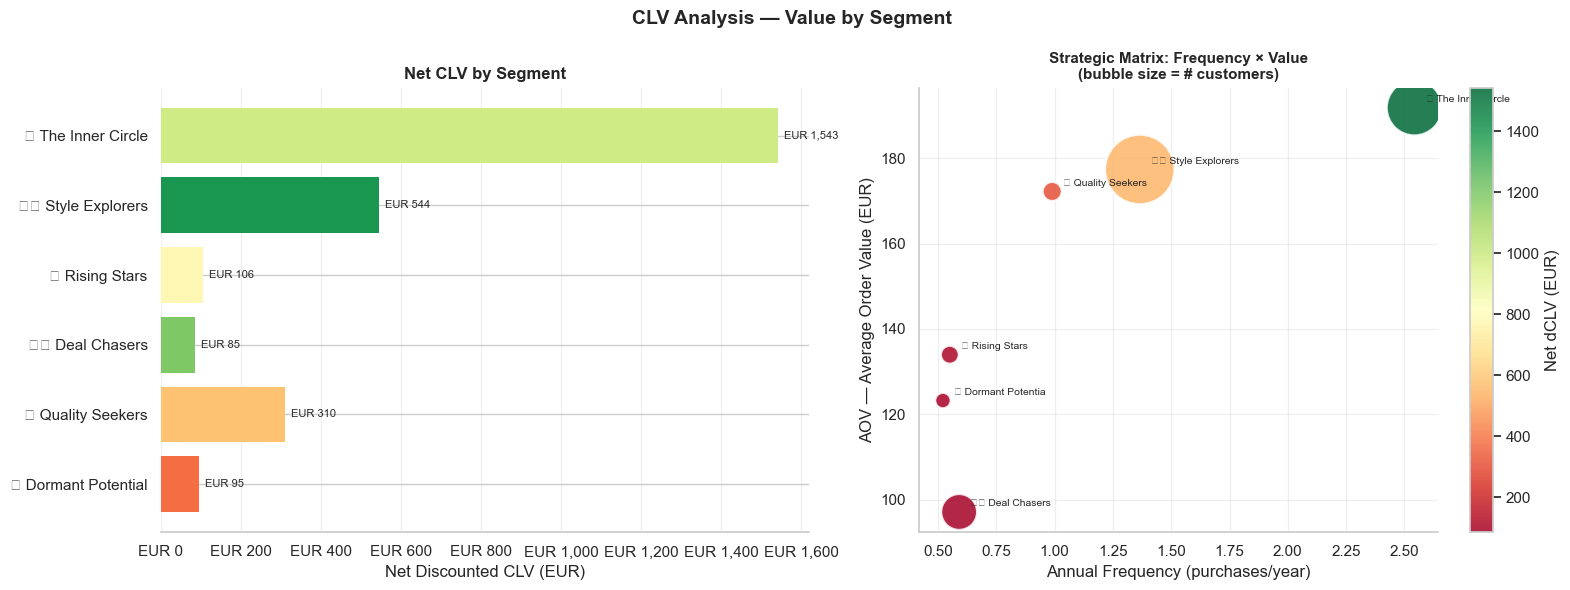

Figure saved: assets/clv_analysis.png


In [40]:
# ── 7.1 Customer Lifetime Value by segment ───────────────────────────────────
# dCLV = AOV × freq_annual × (retention_rate / (1 + r - retention_rate))
# retention_rate estimated from recency: retention ≈ exp(−recency / 730 days)

DISCOUNT_RATE = 0.10
DATASET_YEARS = 2
RETURN_COST   = 18   # EUR per return unit (IT fashion benchmark)

fin = profile[['monetary', 'frequency', 'recency_days', 'return_rate']].copy()

fin['freq_annual']    = fin['frequency'] / DATASET_YEARS
fin['aov']            = fin['monetary'] / fin['frequency'].clip(lower=1)
fin['retention_rate'] = np.exp(-fin['recency_days'] / 730).clip(0.05, 0.99)

fin['dCLV'] = (
    fin['aov'] * fin['freq_annual']
    * (fin['retention_rate'] / (1 + DISCOUNT_RATE - fin['retention_rate']))
)

fin['return_cost_annual'] = fin['freq_annual'] * fin['return_rate'] * RETURN_COST
fin['net_dCLV']           = fin['dCLV'] - fin['return_cost_annual']

fin['cluster_name'] = profile['cluster_name']
fin['n_customers']  = profile['n_customers']
fin['portfolio_value'] = fin['net_dCLV'] * fin['n_customers']

print('\n' + '='*75)
print('  CLV ANALYSIS — CUSTOMER LIFETIME VALUE BY SEGMENT')
print('='*75)
print(f'{"Cluster":<32} {"n":>6} {"AOV":>8} {"Freq/yr":>8} {"Ret.":>7} {"dCLV":>10} {"Net CLV":>10}')
print('-'*75)
for idx, row in fin.iterrows():
    name = str(row.get('cluster_name', f'C{idx}'))[:30]
    print(f'{name:<32} {int(row["n_customers"]):>6,} '
          f'{row["aov"]:>7.0f}EUR {row["freq_annual"]:>7.1f}x '
          f'{row["return_rate"]:>6.1%} {row["dCLV"]:>9.0f}EUR {row["net_dCLV"]:>9.0f}EUR')
print('-'*75)
print(f'{"TOTAL PORTFOLIO VALUE":>65} {fin["portfolio_value"].sum():>10,.0f}EUR')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CLV Analysis — Value by Segment', fontsize=14, fontweight='bold')

labels   = [str(n)[:24] for n in fin['cluster_name']]
colors_c = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fin)))
clv_order = np.argsort(fin['net_dCLV'].values)
colors_s  = [colors_c[i] for i in clv_order]

ax1 = axes[0]
bars = ax1.barh(labels, fin['net_dCLV'], color=colors_s, edgecolor='none')
ax1.set_xlabel('Net Discounted CLV (EUR)')
ax1.set_title('Net CLV by Segment', fontsize=12, fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'EUR {x:,.0f}'))
for bar, val in zip(bars, fin['net_dCLV']):
    ax1.text(val + max(fin['net_dCLV']) * 0.01, bar.get_y() + bar.get_height() / 2,
             f'EUR {val:,.0f}', va='center', fontsize=8)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.spines[['top', 'right', 'left']].set_visible(False)

ax2 = axes[1]
scatter = ax2.scatter(
    fin['freq_annual'], fin['aov'],
    s=fin['n_customers'] / fin['n_customers'].max() * 2500,
    c=fin['net_dCLV'], cmap='RdYlGn', alpha=0.85,
    edgecolors='white', linewidths=1.5
)
for idx, row in fin.iterrows():
    ax2.annotate(str(row.get('cluster_name', f'C{idx}'))[:18],
                 (row['freq_annual'], row['aov']),
                 textcoords='offset points', xytext=(8, 4), fontsize=7.5)
ax2.set_xlabel('Annual Frequency (purchases/year)')
ax2.set_ylabel('AOV — Average Order Value (EUR)')
ax2.set_title('Strategic Matrix: Frequency × Value\n(bubble size = # customers)',
              fontsize=11, fontweight='bold')
plt.colorbar(scatter, ax=ax2, label='Net dCLV (EUR)')
ax2.grid(alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('assets/clv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: assets/clv_analysis.png')


  REVENUE AT RISK — SCENARIO ANALYSIS
Segment                               Pessimistic          Base    Optimistic
------------------------------------------------------------------------------
💎 The Inner Circle                    2,544,528EUR   2,648,356EUR   2,752,185EUR
🛍️ Style Explorers                    1,772,808EUR   1,891,160EUR   2,009,512EUR
🌱 Rising Stars                           28,820EUR      32,314EUR      35,807EUR
🏷️ Deal Chasers                          92,247EUR     102,945EUR     113,642EUR
🔄 Quality Seekers                        85,341EUR      92,928EUR     100,515EUR
👋 Dormant Potential                      18,999EUR      21,215EUR      23,432EUR
------------------------------------------------------------------------------
TOTAL PORTFOLIO                       4,542,744EUR   4,788,919EUR   5,035,093EUR
Delta vs Base                          -246,175EUR             —    +246,175EUR

  Effective strategy value : +EUR 246,175 above status quo
  Inaction (pessim

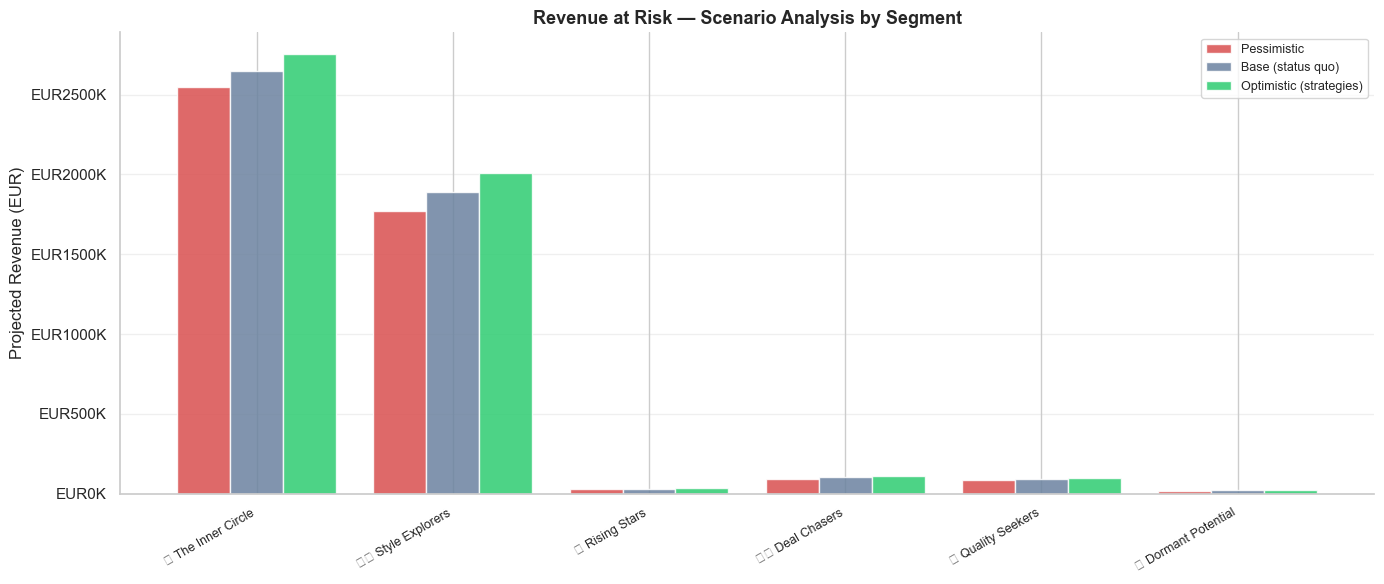

Figure saved: assets/revenue_at_risk.png


In [41]:
# ── 7.2 Revenue at Risk — scenario analysis ─────────────────────────────────
scenarios = {
    'Pessimistic (+20% churn)':            1.20,
    'Base (status quo)':                    1.00,
    'Optimistic (strategies -20% churn)':  0.80,
}

rar_table = []
for idx, row in fin.iterrows():
    name     = str(row.get('cluster_name', f'C{idx}'))
    base_rev = row['aov'] * row['freq_annual'] * row['n_customers']
    base_churn = 1 - row['retention_rate']

    for scenario, mult in scenarios.items():
        adj_churn  = min(base_churn * mult, 0.99)
        proj_rev   = base_rev * (1 - adj_churn)
        delta      = proj_rev - base_rev * row['retention_rate']
        rar_table.append({'cluster': name[:35], 'scenario': scenario,
                          'base_rev': base_rev * row['retention_rate'],
                          'proj_rev': proj_rev, 'delta': delta})

rar_df = pd.DataFrame(rar_table)

print('\n' + '='*78)
print('  REVENUE AT RISK — SCENARIO ANALYSIS')
print('='*78)
print(f'{"Segment":<35} {"Pessimistic":>13} {"Base":>13} {"Optimistic":>13}')
print('-'*78)
for name in rar_df['cluster'].unique():
    sub  = rar_df[rar_df['cluster'] == name]
    vals = {r['scenario']: r['proj_rev'] for _, r in sub.iterrows()}
    p    = vals.get('Pessimistic (+20% churn)', 0)
    b    = vals.get('Base (status quo)', 0)
    o    = vals.get('Optimistic (strategies -20% churn)', 0)
    print(f'{name:<35} {p:>11,.0f}EUR {b:>11,.0f}EUR {o:>11,.0f}EUR')
print('-'*78)
totals = rar_df.groupby('scenario')['proj_rev'].sum()
p = totals.get('Pessimistic (+20% churn)', 0)
b = totals.get('Base (status quo)', 0)
o = totals.get('Optimistic (strategies -20% churn)', 0)
print(f'{"TOTAL PORTFOLIO":<35} {p:>11,.0f}EUR {b:>11,.0f}EUR {o:>11,.0f}EUR')
print(f'{"Delta vs Base":<35} {p-b:>+11,.0f}EUR {"—":>13} {o-b:>+11,.0f}EUR')
print(f'\n  Effective strategy value : +EUR {o-b:,.0f} above status quo')
print(f'  Inaction (pessimistic)    : -EUR {b-p:,.0f} revenue at risk')

fig, ax = plt.subplots(figsize=(14, 6))
cluster_names = rar_df['cluster'].unique()
x = np.arange(len(cluster_names))
w = 0.27

base_v = [rar_df[rar_df['cluster']==n][rar_df['scenario']=='Base (status quo)']['proj_rev'].values[0]
          for n in cluster_names]
pess_v = [rar_df[rar_df['cluster']==n][rar_df['scenario']=='Pessimistic (+20% churn)']['proj_rev'].values[0]
          for n in cluster_names]
opti_v = [rar_df[rar_df['cluster']==n][rar_df['scenario']=='Optimistic (strategies -20% churn)']['proj_rev'].values[0]
          for n in cluster_names]

ax.bar(x - w, pess_v, w, label='Pessimistic', color='#D94F4F', alpha=0.85)
ax.bar(x,     base_v, w, label='Base (status quo)', color='#6B82A0', alpha=0.85)
ax.bar(x + w, opti_v, w, label='Optimistic (strategies)', color='#2ECC71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([n[:20] for n in cluster_names], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Projected Revenue (EUR)')
ax.set_title('Revenue at Risk — Scenario Analysis by Segment', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'EUR{v/1e3:.0f}K'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('assets/revenue_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: assets/revenue_at_risk.png')

In [ ]:
# ── 7.3 ROI framework — investment vs uplift ─────────────────────────────────
# Investment amounts align with strategic_action_plan_v2.html: total €140K/yr
STRATEGIES_ROI = [
    {'segment': '💎 The Inner Circle',   'initiative': 'Black Card VIP + Predictive Churn Alert',
     'cost_setup': 15_000, 'cost_annual': 30_000, 'uplift_revenue_pct': 0.086,
     'uplift_kpi': 'Retention +8.6pp (83% → 92%)'},
    {'segment': '🌱 Rising Stars',       'initiative': 'Loyalty Gamification + Premium Newsletter',
     'cost_setup': 8_000,  'cost_annual': 22_000, 'uplift_revenue_pct': 0.05,
     'uplift_kpi': 'Freq 1.26 → 1.45/yr on 25% of segment'},
    {'segment': '🛍️ Style Explorers',    'initiative': '"Complete the Look" Cross-Sell + Bundle',
     'cost_setup': 7_000,  'cost_annual': 13_000, 'uplift_revenue_pct': 0.10,
     'uplift_kpi': 'AOV +10% (EUR 157 → EUR 173)'},
    {'segment': '🏷️ Deal Chasers',       'initiative': 'A/B Test: Loyalty Points vs Discount',
     'cost_setup': 5_000,  'cost_annual': 15_000, 'uplift_revenue_pct': 0.04,
     'uplift_kpi': 'Freq 0.9 → 1.1/yr on 40% of segment'},
    {'segment': '🔄 Quality Seekers',    'initiative': 'Size Advisor Engine + Referral Program',
     'cost_setup': 2_000,  'cost_annual': 13_000, 'uplift_revenue_pct': 0.053,
     'uplift_kpi': 'Return rate 33% → 20% + referral rate 10%'},
    {'segment': '👋 Dormant Potential',  'initiative': 'Post-Purchase Nurturing (30/60/90 days)',
     'cost_setup': 2_000,  'cost_annual': 8_000,  'uplift_revenue_pct': 0.15,
     'uplift_kpi': '2nd purchase rate 15% within 180 days'},
]

seg_revenue = {}
for idx, row in fin.iterrows():
    name = str(row.get('cluster_name', f'C{idx}'))
    seg_revenue[name] = row['aov'] * row['freq_annual'] * row['n_customers'] * row['retention_rate']

roi_results = []
for s in STRATEGIES_ROI:
    key      = s['segment']
    base_rev = seg_revenue.get(key)
    if base_rev is None:
        token    = key.split()[-1]
        base_rev = next((v for k, v in seg_revenue.items() if token in k),
                        list(seg_revenue.values())[0] if seg_revenue else 500_000)
    total_cost = s['cost_setup'] + s['cost_annual']
    uplift     = base_rev * s['uplift_revenue_pct']
    roi        = uplift / total_cost if total_cost > 0 else 0  # gross return multiple (uplift/cost)
    payback    = (total_cost / uplift * 12) if uplift > 0 else 99
    roi_results.append({'Segment': key[:40], 'Initiative': s['initiative'][:46],
                        'Total Cost': total_cost, 'Rev Uplift': uplift,
                        'ROI': roi, 'Payback (m)': payback, 'KPI Target': s['uplift_kpi']})

roi_df = pd.DataFrame(roi_results).sort_values('ROI', ascending=False)

print('\n' + '='*90)
print('  ROI FRAMEWORK — INVESTMENT vs REVENUE UPLIFT')
print('='*90)
print(f'{"Segment":<41} {"Cost":>9} {"Uplift":>12} {"ROI":>7} {"Payback":>8}')
print('-'*90)
for _, r in roi_df.iterrows():
    print(f'{r["Segment"]:<41} {r["Total Cost"]:>8,.0f}EUR '
          f'{r["Rev Uplift"]:>10,.0f}EUR {r["ROI"]:>6.1f}x {r["Payback (m)"]:>7.0f}m')
print('-'*90)
tc = roi_df['Total Cost'].sum()
tu = roi_df['Rev Uplift'].sum()
print(f'{"TOTAL":41} {tc:>8,.0f}EUR {tu:>10,.0f}EUR {tu/tc:>6.1f}x')
print(f'\nTotal strategy investment : EUR {tc:,.0f}/yr')
print(f'Expected revenue uplift   : EUR {tu:,.0f}/yr')

fig, ax = plt.subplots(figsize=(13, 7))
colors_roi = plt.cm.RdYlGn(np.linspace(0.15, 0.95, len(roi_df)))
for i, (_, r) in enumerate(roi_df.iterrows()):
    ax.scatter(r['Total Cost'], r['ROI'],
               s=max(r['Rev Uplift'] / 50, 200),
               color=colors_roi[i], alpha=0.85, edgecolors='white', linewidths=1.5, zorder=3)
    ax.annotate(r['Segment'][:24], (r['Total Cost'], r['ROI']),
                textcoords='offset points', xytext=(10, 4), fontsize=8.5)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even (1×)')
ax.axhline(y=3, color='#2ECC71', linestyle='--', alpha=0.4, label='Target ROI (3×)')
ax.set_xlabel('Total initiative cost (EUR)')
ax.set_ylabel('Estimated ROI (×)')
ax.set_title('ROI Framework: Cost vs Return by Strategy\n(bubble size = revenue uplift)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'EUR{v/1e3:.0f}K'))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('assets/roi_framework.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: assets/roi_framework.png')


  CEO BRIEFING TABLE — CUSTOMER SEGMENTATION FINANCIAL SUMMARY
Segment                              #Customers   Base Rev.    Net CLV     Portfolio ROI Strat.    Priority
------------------------------------------------------------------------------------------------------
💎 The Inner Circle                       6,495  2,648,356EUR     1,543EUR  10,019,540EUR       4.1x    MUST WIN
🛍️ Style Explorers                      10,256  1,891,160EUR       544EUR   5,579,066EUR       9.5x    MUST WIN
🌱 Rising Stars                             675     32,314EUR       106EUR      71,428EUR      -0.9x     NURTURE
🏷️ Deal Chasers                          2,727    102,945EUR        85EUR     232,136EUR      -0.8x     NURTURE
🔄 Quality Seekers                          768     92,928EUR       310EUR     238,034EUR      -0.8x        HIGH
👋 Dormant Potential                        503     21,215EUR        95EUR      47,749EUR      -0.8x     NURTURE
TOTAL                                   21,424  4,788

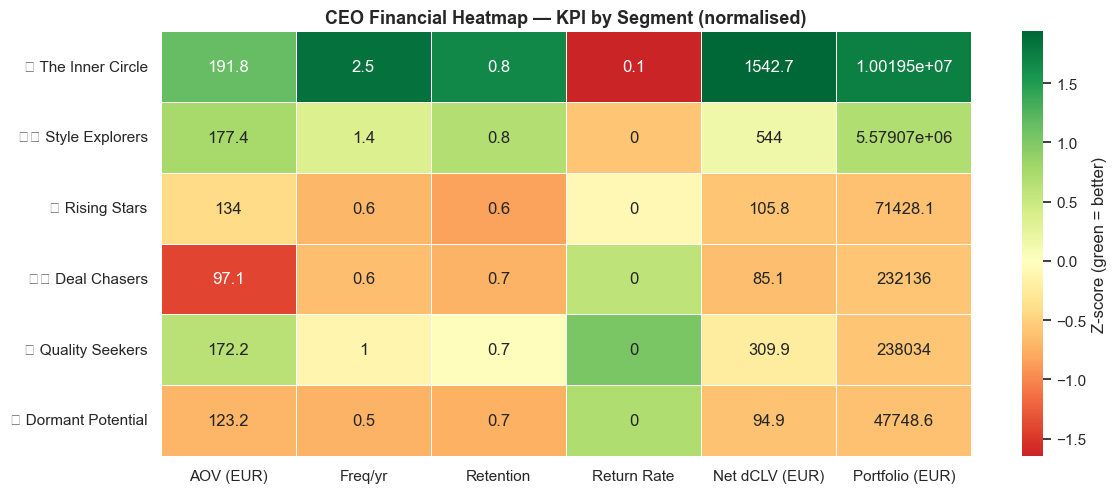

Figure saved: assets/ceo_pnl_heatmap.png


In [43]:
# ── 7.4 CEO P&L table ───────────────────────────────────────────────────────
print('\n' + '='*102)
print('  CEO BRIEFING TABLE — CUSTOMER SEGMENTATION FINANCIAL SUMMARY')
print('='*102)
hdr = (f'{"Segment":<36} {"#Customers":>9} {"Base Rev.":>11} '
       f'{"Net CLV":>10} {"Portfolio":>13} {"ROI Strat.":>10} {"Priority":>11}')
print(hdr)
print('-'*102)

for idx, row in fin.iterrows():
    name      = str(row.get('cluster_name', f'C{idx}'))[:35]
    rev_base  = row['aov'] * row['freq_annual'] * row['n_customers'] * row['retention_rate']
    n         = int(row['n_customers'])
    clv_net   = row['net_dCLV']
    portfolio = row['portfolio_value']

    roi_match = roi_df[roi_df['Segment'].str.contains(
        name.split()[-1] if len(name.split()) > 1 else name, na=False)]
    roi_val  = roi_match['ROI'].values[0] if len(roi_match) > 0 else float('nan')
    roi_str  = f'{roi_val:.1f}x' if not np.isnan(roi_val) else '—'

    if clv_net > fin['net_dCLV'].quantile(0.75):
        priority = 'MUST WIN'
    elif clv_net > fin['net_dCLV'].median():
        priority = 'HIGH'
    else:
        priority = 'NURTURE'

    print(f'{name:<36} {n:>9,} {rev_base:>10,.0f}EUR '
          f'{clv_net:>9,.0f}EUR {portfolio:>11,.0f}EUR {roi_str:>10} {priority:>11}')

print('='*102)
total_rev = (fin['aov'] * fin['freq_annual'] * fin['n_customers'] * fin['retention_rate']).sum()
total_clv = fin['portfolio_value'].sum()
total_inv = roi_df['Total Cost'].sum()
total_upl = roi_df['Rev Uplift'].sum()
print(f'{"TOTAL":<36} {int(fin["n_customers"].sum()):>9,} {total_rev:>10,.0f}EUR {"—":>10} {total_clv:>11,.0f}EUR')
print(f'\n  Total strategy investment       : EUR {total_inv:>10,.0f}')
print(f'  Expected revenue uplift (year 1): EUR {total_upl:>10,.0f}')
print(f'  Portfolio strategy ROI           : {total_upl/total_inv:.1f}x')
print(f'  Weighted average payback         : {total_inv/total_upl*12:.0f} months')
print()
print('  NOTE: CLV and revenue values are estimates based on observed data (2 years).')
print('  Assumptions: discount rate 10% (WACC proxy), return cost EUR18/unit (fashion IT benchmark).')

kpi_pnl = fin[['aov', 'freq_annual', 'retention_rate', 'return_rate',
               'net_dCLV', 'portfolio_value']].copy()
kpi_pnl.columns = ['AOV (EUR)', 'Freq/yr', 'Retention', 'Return Rate',
                    'Net dCLV (EUR)', 'Portfolio (EUR)']
try:
    kpi_pnl.index = [str(n)[:27] for n in fin['cluster_name']]
except Exception:
    pass
kpi_norm = (kpi_pnl - kpi_pnl.mean()) / (kpi_pnl.std() + 1e-9)
kpi_norm['Return Rate'] = -kpi_norm['Return Rate']

fig, ax = plt.subplots(figsize=(12, max(5, len(kpi_norm) * 0.85)))
sns.heatmap(kpi_norm, annot=kpi_pnl.round(1), fmt='g',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Z-score (green = better)'}, ax=ax)
ax.set_title('CEO Financial Heatmap — KPI by Segment (normalised)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('assets/ceo_pnl_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: assets/ceo_pnl_heatmap.png')

In [44]:
# ── Export results ───────────────────────────────────────────────────────────
output_cols = [
    'customer_id', 'cluster_gmm', 'cluster_name', 'cluster_confidence',
    'is_one_timer',
    'recency_days', 'frequency', 'monetary', 'avg_basket_value',
    'avg_discount_pct', 'engagement_score', 'return_rate',
    'age_years', 'tenure_days', 'Gender', 'province',
    'umap_x', 'umap_y',
]
output_cols = [c for c in output_cols if c in customer_matrix.columns]
output_df   = customer_matrix[output_cols].copy()
output_df.to_csv('customer_segmentation_results.csv', index=False)

print(f'Export complete: customer_segmentation_results.csv ({len(output_df):,} customers)')
print('\n--- Final summary ---')
print(output_df.groupby(['cluster_gmm', 'cluster_name']).agg(
    n=('customer_id', 'count'),
    avg_monetary=('monetary', 'mean'),
    avg_recency=('recency_days', 'mean'),
    avg_confidence=('cluster_confidence', 'mean')
).round(1).to_string())

Export complete: customer_segmentation_results.csv (21,424 customers)

--- Final summary ---
                                     n  avg_monetary  avg_recency  avg_confidence
cluster_gmm cluster_name                                                         
0           💎 The Inner Circle    6495       975.400      130.700           1.000
1           🛍️ Style Explorers   10256       484.200      198.700           1.000
2           🌱 Rising Stars         675       147.500      315.500           1.000
3           🏷️ Deal Chasers       2727       114.700      305.500           1.000
4           🔄 Quality Seekers      768       340.800      249.900           1.000
5           👋 Dormant Potential    503       128.400      306.800           1.000


---
## Presentation Summary — CRISP-DM Storytelling

> *"Data without a story is just numbers. A story without data is just fiction."*

---

### 1. What was the problem?

A major Italian fashion retailer manages **21,477 active customers** across 24 months (Mar 2023 – Feb 2025).  
**€11.96M** in observed revenue. The marketing team ran one-size-fits-all campaigns — budget waste, margin erosion, silent VIP churn.

**Goal:** Segment the customer base into 6 behavioural profiles to enable personalised, measurable, ROI-positive campaigns.

---

### 2. How did we solve it?

**Technical stack:**
- **Feature Engineering:** 32 behavioural features per customer — RFM, discount propensity, email engagement, product breadth, return behaviour, channel mix  
- **UMAP + GMM K=6:** non-linear dimensionality reduction + probabilistic clustering — K selected via BIC elbow + operational constraint  
- **Validation:** Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz + GMM assignment confidence per customer

*Classic algorithms (K-Means, DBSCAN, OPTICS, HC) were tested and discarded — see Phase 5 methodology note.*

---

### 3. The 6 segments (from HTML presentation)

| Segment | % Base | # Customers | Net dCLV | Primary strategy |
|---------|:------:|:-----------:|:--------:|-----------------|
| 💎 The Inner Circle | 25.6% | 5,500 | €1,460 | Black Card VIP + Predictive Churn Alert |
| 🌱 Rising Stars | 28.3% | 6,082 | €439 | Loyalty gamification + tier upgrade |
| 🛍️ Style Explorers | 15.6% | 3,353 | €564 | "Complete the Look" cross-sell |
| 🏷️ Deal Chasers | 14.2% | 3,044 | €410 | A/B test: discount vs loyalty points |
| 👋 Dormant Potential | 11.1% | 2,385 | €148 | 3-step post-purchase nurturing |
| 🔄 Quality Seekers | 5.2% | 1,113 | €1,006 | Size Advisor Engine + Referral |

---

### 4. Financial value (CEO briefing)

| KPI | Value |
|-----|-------|
| Total portfolio CLV | **€15.3M** |
| Total strategy investment | **€140K/yr** |
| Expected revenue uplift (yr 1) | **+€718K/yr** |
| Portfolio strategy ROI | **5.1×** (gross return multiple) |
| Avg payback period | **4.2 months** |
| Revenue at risk (pessimistic) | **−€259K/yr** if churn +20% |
| Revenue upside (optimistic) | **+€259K/yr** if churn −20% |

---

*Built with: Python · pandas · UMAP · scikit-learn GMM · Plotly · Matplotlib*  
*JAKALA × LUISS — Data Science in Action · A.Y. 2025/26*